In [28]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [3]:
# check for missing values
print(df.isnull().sum())

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64


In [4]:
# Fill age with the average age
df["Age"] = df["Age"].fillna(df["Age"].mean())
# Fill Session_Duration with the average session duration
df["Session_Duration_Avg"] = df["Session_Duration_Avg"].fillna(df["Session_Duration_Avg"].mean())
# Fill pages per session with the average pages per session
df["Pages_Per_Session"] = df["Pages_Per_Session"].fillna(df["Pages_Per_Session"].mean())
#Fill wishlist items with 0
df["Wishlist_Items"] = df["Wishlist_Items"].fillna(0)
# Fill Days since last purchase with median
df["Days_Since_Last_Purchase"] = df["Days_Since_Last_Purchase"].fillna(df["Days_Since_Last_Purchase"].median())
# Fill Discount usage rate with average discount usage rate
df["Discount_Usage_Rate"] = df["Discount_Usage_Rate"].fillna(df["Discount_Usage_Rate"].mean())
# Fill Return rate with 0
df["Returns_Rate"] = df["Returns_Rate"].fillna(0)
#Fill Email Open rate with 0
df["Email_Open_Rate"] = df["Email_Open_Rate"].fillna(0)
#Fill customer service calls with 0
df["Customer_Service_Calls"] = df["Customer_Service_Calls"].fillna(0)
# Fill Product Reviews Written with 0
df["Product_Reviews_Written"] = df["Product_Reviews_Written"].fillna(0)
# fill Social Media Engagement Score with 0
df["Social_Media_Engagement_Score"] = df["Social_Media_Engagement_Score"].fillna(0)
# Fill Mobile App Usage with 0
df["Mobile_App_Usage"] = df["Mobile_App_Usage"].fillna(0)
# Fill Payment Method Diversity with median
df["Payment_Method_Diversity"] = df["Payment_Method_Diversity"].fillna(df["Payment_Method_Diversity"].median())
# Fill credit balance with median
df["Credit_Balance"] = df["Credit_Balance"].fillna(df["Credit_Balance"].median())
df.isnull().sum()

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            50000 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           50000 non-null  float64
 7   Pages_Per_Session              50000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 50000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       50000 non-null  float64
 1

In [6]:
#count churned
print(df["Churned"].value_counts())
# churned %
print(df["Churned"].value_counts(normalize=True)*100)

Churned
0    35550
1    14450
Name: count, dtype: int64
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


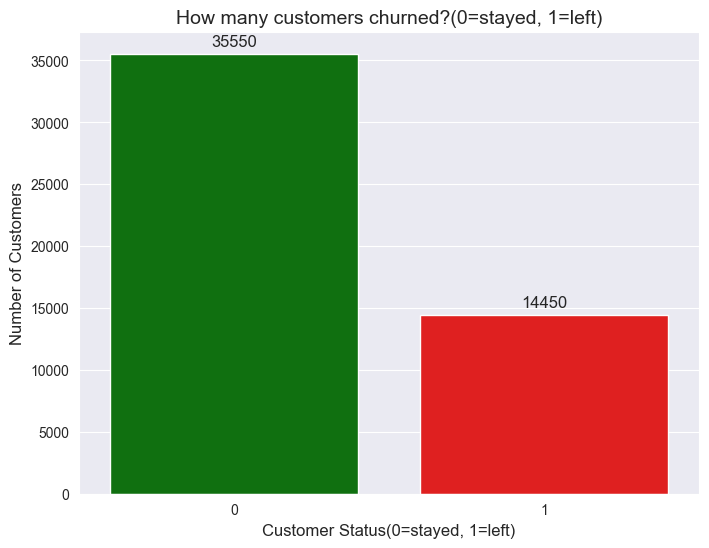

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
ax = sns.countplot(x= "Churned", data = df, hue="Churned",palette={0: "green", 1: "red"},
    legend=False)
plt.title("How many customers churned?(0=stayed, 1=left)", fontsize=14)
plt.xlabel('Customer Status(0=stayed, 1=left)', fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
for bar in ax.containers:
    ax.bar_label(bar, fontsize=12, padding=3)
plt.show()

In [9]:
# avg number of loyal and churned customers
analysis_table = df.groupby('Churned').mean(numeric_only=True)
print(analysis_table)

               Age  Membership_Years  Login_Frequency  Session_Duration_Avg  \
Churned                                                                       
0        38.541680          2.984828        12.642391             29.119763   
1        35.985583          2.981996         9.120830             24.071290   

         Pages_Per_Session  Cart_Abandonment_Rate  Wishlist_Items  \
Churned                                                             
0                 9.262994              54.194460        4.324641   
1                 7.445750              64.178935        3.043945   

         Total_Purchases  Average_Order_Value  Days_Since_Last_Purchase  \
Churned                                                                   
0              13.827522           118.383907                 26.541322   
1              11.350201           134.762532                 35.966851   

         Discount_Usage_Rate  Returns_Rate  Email_Open_Rate  \
Churned                                   

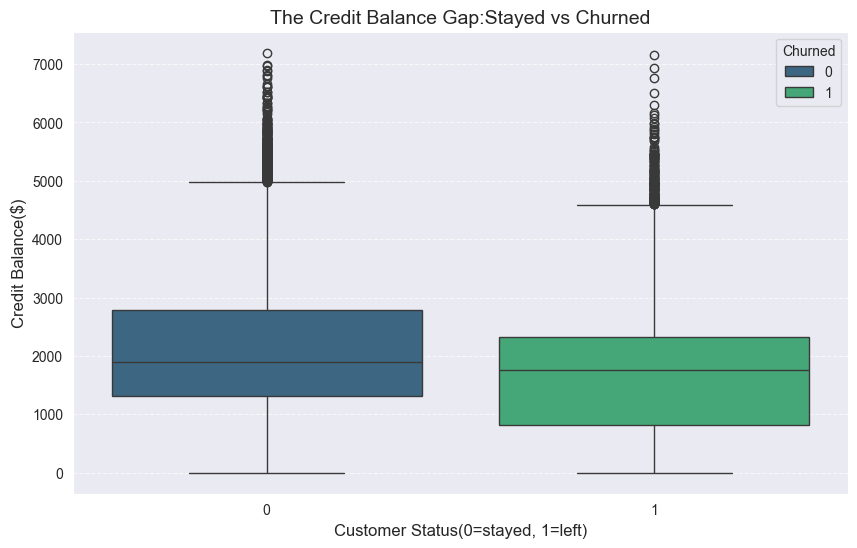

In [16]:
#Effect of credit balance on customer churn
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x ='Churned', y='Credit_Balance', data= df, hue="Churned", palette='viridis')
plt.title('The Credit Balance Gap:Stayed vs Churned', fontsize=14)
plt.xlabel('Customer Status(0=stayed, 1=left)', fontsize=12)
plt.ylabel('Credit Balance($)', fontsize=12)
plt.grid(axis='y', linestyle= "--", alpha = 0.7)
plt.show()

In [17]:
print(df.groupby('Churned')['Credit_Balance'].describe())

           count         mean          std  min     25%     50%      75%  \
Churned                                                                    
0        35550.0  2067.570408  1147.276071  0.0  1312.0  1896.0  2780.00   
1        14450.0  1690.190450  1133.184203  0.0   822.0  1762.5  2332.75   

            max  
Churned          
0        7197.0  
1        7160.0  


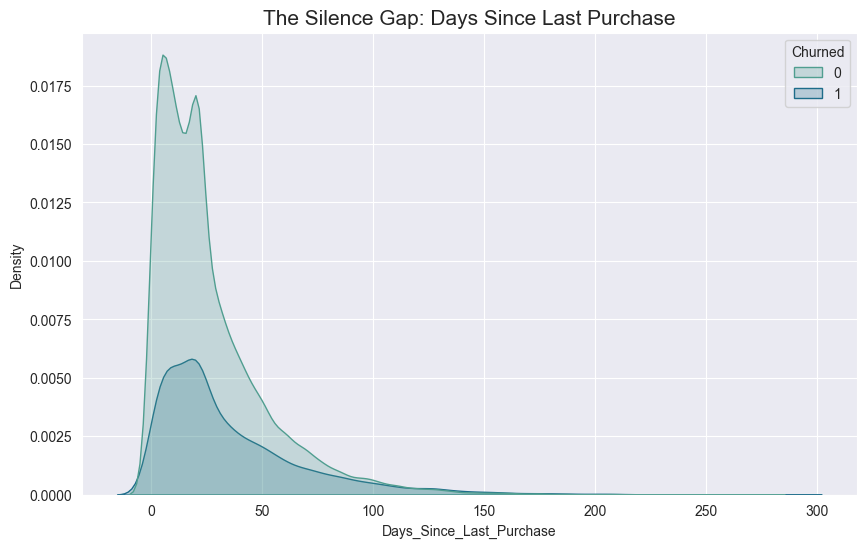

In [18]:
#Days since last purchase distribution for loyal and churned customers
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Days_Since_Last_Purchase', hue = 'Churned', fill=True, palette='crest')
plt.title('The Silence Gap: Days Since Last Purchase', fontsize= 15)
plt.show()

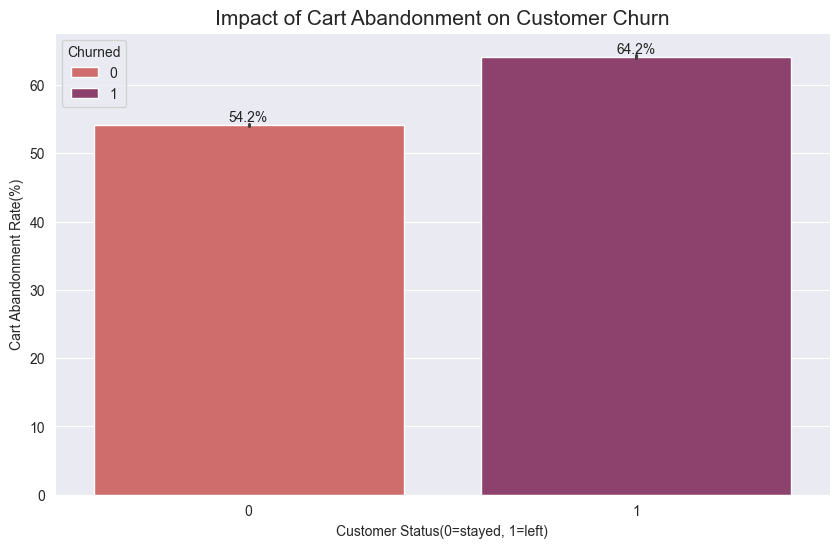

In [23]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Churned', y='Cart_Abandonment_Rate', data = df, hue ='Churned', palette='flare')
plt.title('Impact of Cart Abandonment on Customer Churn', fontsize=15)
plt.xlabel("Customer Status(0=stayed, 1=left)")
plt.ylabel("Cart Abandonment Rate(%)")
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%')
plt.show()


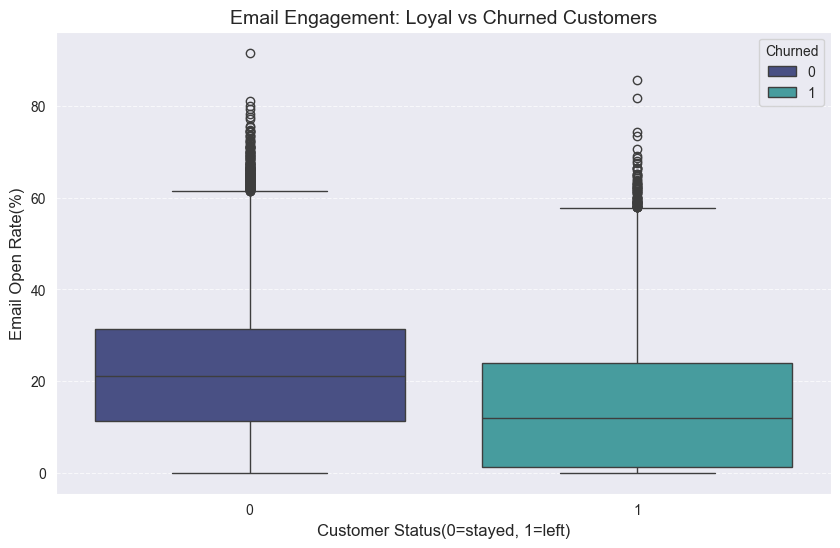

In [26]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(x='Churned', y='Email_Open_Rate', data= df, hue='Churned', palette='mako')
plt.title("Email Engagement: Loyal vs Churned Customers", fontsize=14)
plt.xlabel("Customer Status(0=stayed, 1=left)", fontsize=12)
plt.ylabel("Email Open Rate(%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

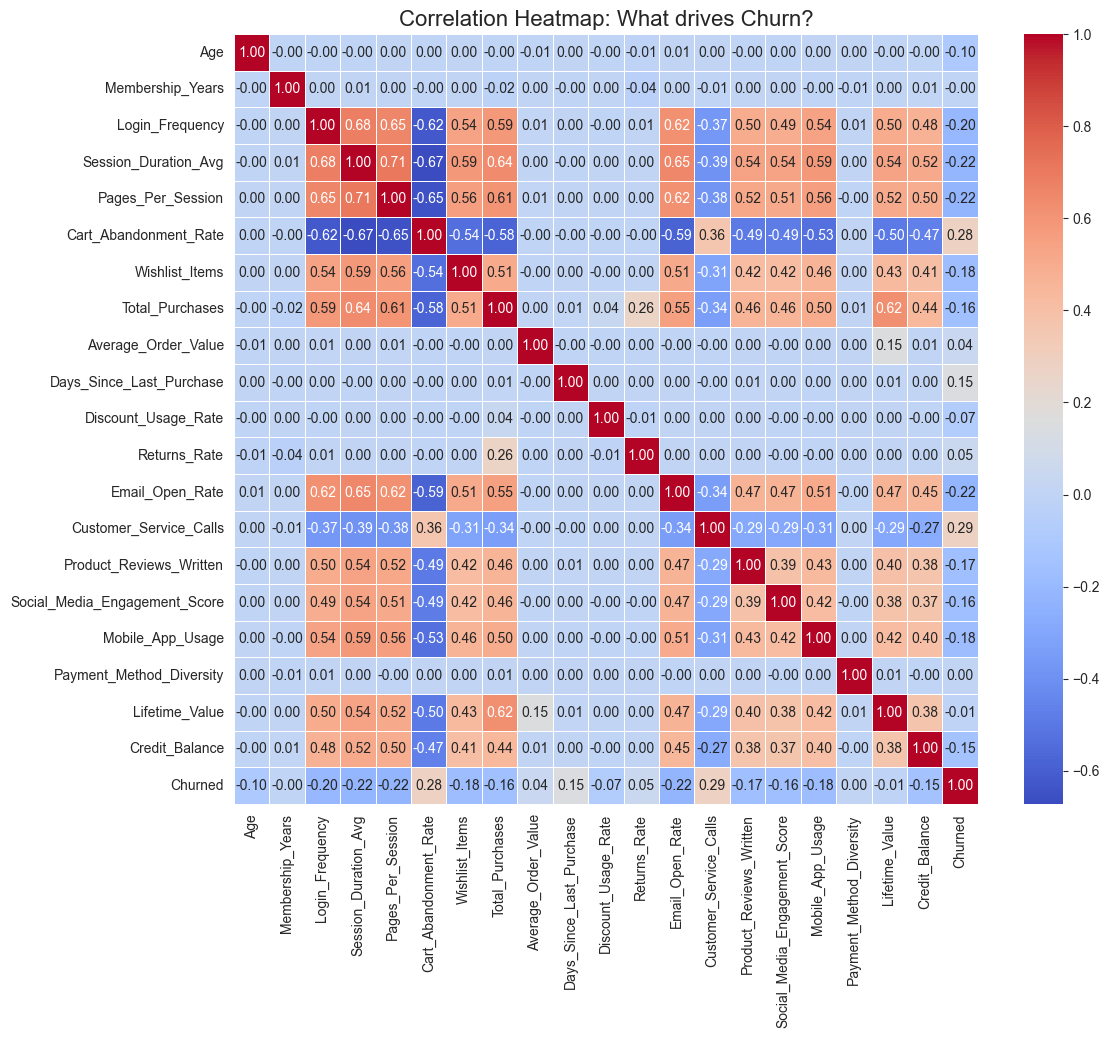

In [30]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap ='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: What drives Churn?', fontsize = 16)
plt.show()

In [32]:
#Create a simple score: Customers with high calls and high abandonment get a high score
df['Risk_Score'] = df['Customer_Service_Calls'] + (df['Cart_Abandonment_Rate']/10)
# top 5 highest risk customers who haven't churned yet
potential_churners = df[df['Churned'] == 0].sort_values(by = 'Risk_Score', ascending=False)
print(potential_churners[['Credit_Balance', 'Risk_Score']].head())

       Credit_Balance  Risk_Score
48128          1896.0   25.374335
6975           1896.0   24.950000
12366          2749.0   23.690000
42183           948.0   23.150000
17731          1745.0   23.000000


**Executive Summary: E-commerce Customer Churn Analysis**
1. Project Goal
The objective of this analysis was to identify the ** key behavioral and financial drivers ** behind customer churn (28.9% of the user base) and provide actionable recommendations to increase retention.

______

2. Top 3 Insights
The Inactivity Warning: **Churned customers wait an average of 36 days** between purchases, compared to only 26 days for loyal customers.

The Engagement Gap: There is a **strong negative correlation (-0.49) between Social Media Engagement and churn**. Customers who don't interact with our social content are twice as likely to leave.

Checkout Friction: **Churned customers have a 10% higher Cart Abandonment Rate**, suggesting issues with the final checkout experience or hidden costs.

______

3. Strategic Recommendations
Win-Back Campaign: Automate a "We Miss You" email with a personalized discount code once a customer hits 30 days of inactivity.

Community Building: Invest in social media loyalty programs. Since engagement is the best "shield" against churn, we should reward users for interacting with our posts.

Checkout Optimization: Investigate the checkout flow for users with high abandonment rates. Reducing friction here could save roughly 10% of at-risk users.

______

4. Proactive Retention
Using a custom Risk Score model, we have identified specific high-value customers (e.g., ID 48128) who are currently "Loyal" but show high-risk behaviors. These users should be prioritized for immediate customer success outreach.